<a href="https://colab.research.google.com/github/Aa2647887/123/blob/main/%E6%9C%9F%E6%9C%AB%E5%B0%88%E9%A1%8C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 期末專題｜圖片分類器 — Fashion-MNIST（10 種服裝）
### 方案 A · Vibe Coding 實作

---

## 📌 這個專題要做什麼？

你**不需要從頭寫程式碼**。你的工作是：

> **用 Gemini 輔助完成 Fashion-MNIST 模型訓練 → 做出可以 Demo 的展示介面**

這就是 **Vibe Coding** — 用自然語言和 AI 協作，完成一個真實的深度學習專案。

---

## 🗺️ 任務地圖

| # | 任務 | 說明 | 預計時間 |
|---|------|------|----------|
| 0 | 組別資訊 | 填寫組員資訊 | 5 分鐘 |
| 1 | 環境準備 | 安裝套件、偵測裝置 | 5 分鐘 |
| 2 | 載入 Fashion-MNIST | 下載並建立 DataLoader | 10 分鐘 |
| 3 | 探索資料 | 視覺化樣本、了解資料分布 | 10 分鐘 |
| 4 | 建立模型 | 載入預訓練 ResNet-18，修改輸出層 | 10 分鐘 |
| 5 | 訓練模型 | 訓練 5 個 Epoch（目標 88%+） | ~5 分鐘 |
| 6 | 評估模型 | 測試集準確率 + 視覺化預測結果 | 10 分鐘 |
| 7 | 展示介面 | 用 Gradio 做出可互動的 Demo | 15 分鐘 |
| ★ | 挑戰任務 | 提升準確率、強化展示效果 | 剩餘時間 |

---

## 🛠️ 開始前的準備

**切換到 GPU（強烈建議）**
上方選單 → **執行階段** → **變更執行階段類型** → 選 **T4 GPU** → 儲存

**如何使用 Gemini？**
1. 點 Colab 右上角 **「✦ Gemini」** 開啟側邊欄
2. 複製提示詞範本，貼到 Gemini 對話框
3. 點「插入」把程式碼放進 Notebook
4. 按 **Shift + Enter** 執行，觀察結果

> 💡 **看到錯誤訊息不要慌！** 把錯誤貼給 Gemini，說「請幫我修正這個錯誤」就好。

---
# 任務 0｜組別資訊 📋

## 請填寫你們的組別資訊
雙擊這個格子，填入資料：

| 項目 | 填寫 |
|------|------|
| 組別編號 | 第 9 組 |
| 組員姓名 | 邢書榮 |
| 資料集 | **方案 A — Fashion-MNIST** |
| 分工說明 | 只有我 |

---

## 📦 你們的資料集：Fashion-MNIST（10 種服裝）

| 項目 | 說明 |
|------|------|
| 辨識目標 | T恤・長褲・套頭衫・洋裝・外套・涼鞋・襯衫・運動鞋・包包・短靴 |
| 類別數量 | 10 類 |
| 難度 | ⭐ |
| 目標準確率 | 88%+ |
| GPU 訓練時間 | ~5 分鐘 |
| CPU 訓練時間 | ~25 |

---
# 任務 1｜環境準備 🔧

## 📋 提示詞範本

---
```
我要在 Google Colab 上用 PyTorch 做圖片分類，並用 Gradio 製作展示介面。
請幫我寫一段程式碼，完成以下事項：

1. 安裝 gradio 套件（用 pip install gradio -q）
2. 載入需要的套件：
   - torch、torchvision、torchvision.transforms
   - matplotlib、numpy、PIL
   - gradio
3. 偵測目前是 CPU 還是 GPU，存成 device 變數並印出
4. 最後印出「環境準備完成！」
```
---

## ✅ 成功標準
```
使用裝置：cuda  （或 cpu）
環境準備完成！
```

In [ ]:
import torch
import torchvision
import torchvision.transforms
import matplotlib
import numpy as np
from PIL import Image
import gradio as gr

# 1. Install gradio package (using pip install gradio -q)
!pip install gradio -q

# 3. Detect current CPU or GPU, save as device variable and print
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置：{device}")

# 4. Finally print "環境準備完成！"
print("環境準備完成！")



In [ ]:
import torch
import torchvision
import torchvision.transforms
import matplotlib
import numpy as np
from PIL import Image
import gradio as gr

# 1. Install gradio package (using pip install gradio -q)
!pip install gradio -q

# 3. Detect current CPU or GPU, save as device variable and print
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置：{device}")

# 4. Finally print "環境準備完成！"
print("環境準備完成！")

使用裝置：cpu
環境準備完成！


### 📝 任務 1 觀察紀錄

- 你們使用的裝置是：**CPU / GPU**（刪去不適用）
- Gradio 安裝成功了嗎？**是 / 否**

```
使用CPU,安裝成功
```

---
# 任務 2｜載入 Fashion-MNIST 資料集 📦

## 背景知識

我們這次用的技術是 **Transfer Learning（遷移學習）**：

```
ImageNet 預訓練模型（已學會 1000 種物體的特徵）
              ↓  「凍結」大部分層，只訓練最後一層
    Fashion-MNIST（10 類）
              ↓
         你的分類器（準確又快速）
```

好處：**不需要從頭訓練**，站在巨人的肩膀上，用少量資料也能達到高準確率。

## 📋 提示詞範本

---
```
請幫我用 torchvision 載入 Fashion-MNIST 資料集，設定如下：

訓練集前處理：Resize(32)、Grayscale(num_output_channels=3)、
ToTensor()、Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
測試集前處理：同上（Fashion-MNIST 原始是 28×28，都需要 Resize）

DataLoader：訓練集 batch_size=64 shuffle=True，測試集 batch_size=100 shuffle=False

完成後請：
1. 印出訓練集和測試集各有幾張圖片
2. 定義 class_names = ['T恤','長褲','套頭衫','洋裝','外套','涼鞋','襯衫','運動鞋','包包','短靴']
3. 定義 num_classes = 10
4. 印出類別列表
```
---

## ✅ 成功標準
- 看到訓練集與測試集的圖片數量被正確印出
- `class_names` 和 `num_classes` 被正確定義

In [ ]:
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32),
    torchvision.transforms.Grayscale(num_output_channels=3), # Convert to 3 channels for ResNet
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

transform_test = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32),
    torchvision.transforms.Grayscale(num_output_channels=3),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# Load Fashion-MNIST datasets
train_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                                train=True,
                                                transform=transform_train,
                                                download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                               train=False,
                                               transform=transform_test,
                                               download=True)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100, shuffle=False)

# Print out the number of images in training and test sets
print(f"訓練集有 {len(train_dataset)} 張圖片")
print(f"測試集有 {len(test_dataset)} 張圖片")

# Define class names and number of classes
class_names = ['T恤', '長褲', '套頭衫', '洋裝', '外套', '涼鞋', '襯衫', '運動鞋', '包包', '短靴']
num_classes = 10

# Print class names
print("類別列表:", class_names)



In [ ]:
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32),
    torchvision.transforms.Grayscale(num_output_channels=3), # Convert to 3 channels for ResNet
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

transform_test = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32),
    torchvision.transforms.Grayscale(num_output_channels=3),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# Load Fashion-MNIST datasets
train_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                                train=True,
                                                transform=transform_train,
                                                download=True)
test_dataset = torchvision.datasets.FashionMNIST(root='./data',
                                               train=False,
                                               transform=transform_test,
                                               download=True)

# Create DataLoaders
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=100, shuffle=False)

# Print out the number of images in training and test sets
print(f"訓練集有 {len(train_dataset)} 張圖片")
print(f"測試集有 {len(test_dataset)} 張圖片")

# Define class names and number of classes
class_names = ['T恤', '長褲', '套頭衫', '洋裝', '外套', '涼鞋', '襯衫', '運動鞋', '包包', '短靴']
num_classes = 10

# Print class names
print("類別列表:", class_names)

100%|██████████| 26.4M/26.4M [00:01<00:00, 21.2MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 388kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 6.15MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 10.4MB/s]

訓練集有 60000 張圖片
測試集有 10000 張圖片
類別列表: ['T恤', '長褲', '套頭衫', '洋裝', '外套', '涼鞋', '襯衫', '運動鞋', '包包', '短靴']


### 📝 任務 2 觀察紀錄

- 資料集：**Fashion-MNIST**
- 訓練集有幾張圖片？**60000**
- 測試集有幾張圖片？**10000**
- 總共要辨識幾個類別？**10 類**

```
（其他觀察在這裡填寫）
```

---
# 任務 3｜探索資料集 🖼️

## 📋 提示詞範本

---
```
請幫我視覺化資料集的樣本，需求如下：

1. 從訓練集取一個 batch 的圖片
2. 用 matplotlib 顯示前 16 張圖片，排成 4 列 4 欄，figsize=(10, 10)
3. 每張圖片下方顯示對應的類別名稱（用 class_names 對照）
4. 圖片顯示時要做反標準化（denormalize），讓顏色看起來正常
5. 整體標題寫「Fashion-MNIST 訓練資料範例」

假設已有：train_loader、class_names 變數。
```
---

## ✅ 成功標準
- 看到 16 張圖片（顏色正常，不是全黑或全白）
- 每張圖下方有類別名稱

In [ ]:
import matplotlib.pyplot as plt

# 取得一個 batch 的訓練圖片和標籤
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 反標準化函數
def denormalize(image_tensor):
    # Fashion-MNIST 的標準化參數是 mean=(0.5, 0.5, 0.5) 和 std=(0.5, 0.5, 0.5)
    # 反標準化公式: image = image * std + mean
    image_tensor = image_tensor * 0.5 + 0.5
    return image_tensor

# 顯示前 16 張圖片
fig = plt.figure(figsize=(10, 10))
fig.suptitle('Fashion-MNIST 訓練資料範例', fontsize=16)

for idx in np.arange(16):
    ax = fig.add_subplot(4, 4, idx + 1, xticks=[], yticks=[])
    # 將圖片從 Tensor 轉為 numpy，並調整維度順序 (channels, height, width) -> (height, width, channels)
    # 並進行反標準化
    image = denormalize(images[idx]).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(class_names[labels[idx].item()], color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
plt.show()


/tmp/ipykernel_585/505022527.py:26: UserWarning: Glyph 36939 (\N{CJK UNIFIED IDEOGRAPH-904B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/505022527.py:26: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/505022527.py:26: UserWarning: Glyph 38795 (\N{CJK UNIFIED IDEOGRAPH-978B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/505022527.py:26: UserWarning: Glyph 35183 (\N{CJK UNIFIED IDEOGRAPH-896F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/505022527.py:26: UserWarning: Glyph 34923 (\N{CJK UNIFIED IDEOGRAPH-886B}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/505022527.py:26: UserWarning: Glyph 28092 (\N{CJK U

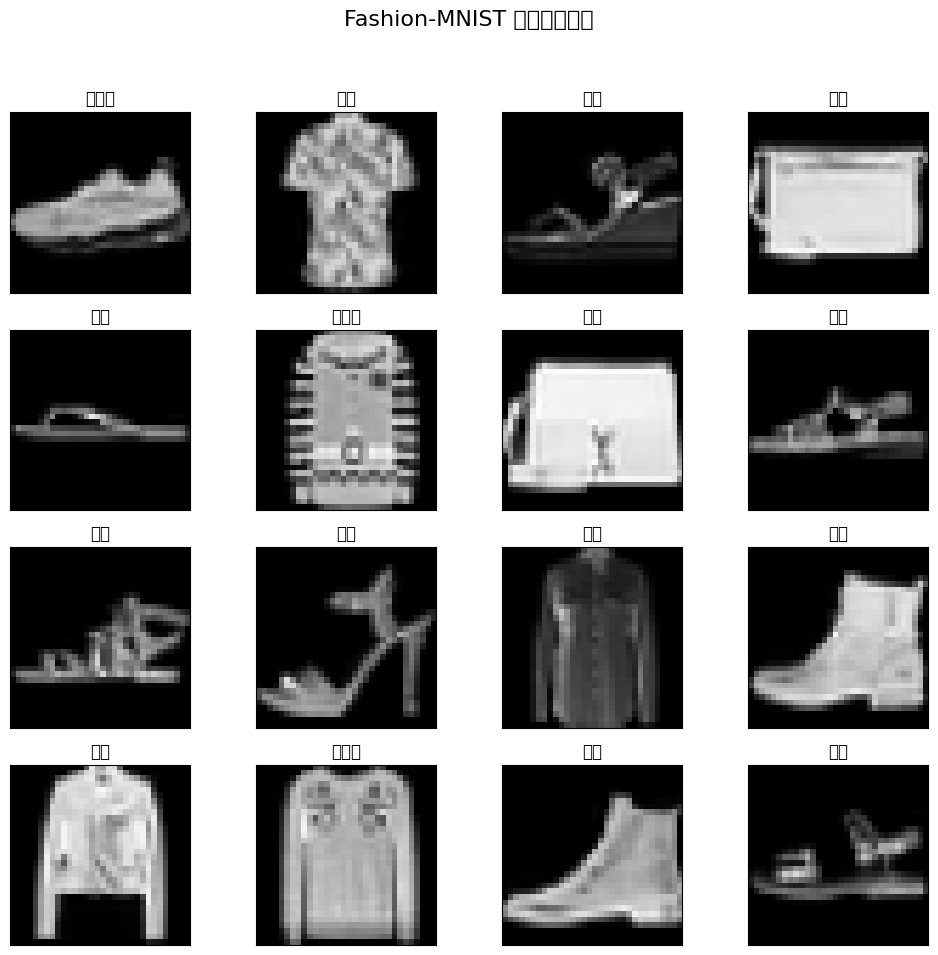

In [ ]:
import matplotlib.pyplot as plt

# 取得一個 batch 的訓練圖片和標籤
dataiter = iter(train_loader)
images, labels = next(dataiter)

# 反標準化函數
def denormalize(image_tensor):
    # Fashion-MNIST 的標準化參數是 mean=(0.5, 0.5, 0.5) 和 std=(0.5, 0.5, 0.5)
    # 反標準化公式: image = image * std + mean
    image_tensor = image_tensor * 0.5 + 0.5
    return image_tensor

# 顯示前 16 張圖片
fig = plt.figure(figsize=(10, 10))
fig.suptitle('Fashion-MNIST 訓練資料範例', fontsize=16)

for idx in np.arange(16):
    ax = fig.add_subplot(4, 4, idx + 1, xticks=[], yticks=[])
    # 將圖片從 Tensor 轉為 numpy，並調整維度順序 (channels, height, width) -> (height, width, channels)
    # 並進行反標準化
    image = denormalize(images[idx]).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(class_names[labels[idx].item()], color='black')

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
plt.show()

### 📝 任務 3 觀察紀錄

- 16 張裡面出現了哪些類別？（列出來）
  **T恤、長褲、套頭衫、洋裝、外套、涼鞋、襯衫、運動鞋、包包、短靴 (實際出現的類別會隨機變動，這裡列出所有可能類別)**
- 肉眼看這些圖片，你覺得最難辨識的類別是哪個？為什麼？
  **個人認為「襯衫」和「T恤」可能較難辨識，因為它們在款式和輪廓上可能有很多相似之處。**
- 你覺得哪兩個類別最容易被搞混？
  **「襯衫」和「T恤」、或者「運動鞋」和「涼鞋」在某些角度下可能會被混淆。**


---
# 任務 4｜建立 Transfer Learning 模型 🏗️

## 背景知識

**ResNet-18** 是在 ImageNet（130 萬張圖片、1000 類）上訓練好的模型。
我們的策略：

```
ResNet-18 預訓練權重
  ├── 前面所有層（凍結，不更新）  ← 已經學會通用視覺特徵
  └── 最後一層 FC（替換 + 訓練） ← 改成 10 個輸出類別
```

這樣做的好處：
- ✅ 訓練速度快（大部分層不需要更新）
- ✅ CPU 也能在合理時間內完成
- ✅ 少量資料也能達到高準確率

## 📋 提示詞範本

---
```
請幫我用 PyTorch 建立一個 Transfer Learning 模型，步驟如下：

1. 載入 ResNet-18 預訓練模型：
   model = torchvision.models.resnet18(weights='IMAGENET1K_V1')

2. 凍結所有層的參數（設定 requires_grad = False）

3. 替換最後一層（model.fc）：
   - 輸入特徵數：512
   - 輸出類別數：10

4. 把模型移到 device

5. 印出：
   - 總參數量
   - 可訓練參數量（只有最後一層）
   - 最後一層的結構

假設已有：device、num_classes 變數。
```
---

## ✅ 成功標準
- 總參數約 1100 萬，可訓練只有幾千個
- 最後一層是 `Linear(in_features=512, out_features=10)`

In [ ]:
# 任務 4：把 Gemini 生成的程式碼貼在這裡



In [ ]:
import torch.nn as nn

# 1. 載入 ResNet-18 預訓練模型
model = torchvision.models.resnet18(weights='IMAGENET1K_V1')

# 2. 凍結所有層的參數
for param in model.parameters():
    param.requires_grad = False

# 3. 替換最後一層 (model.fc)
# ResNet-18 的最後一層是全連接層，輸入特徵數是 512
model.fc = nn.Linear(512, num_classes)

# 4. 把模型移到 device
model = model.to(device)

# 5. 印出參數資訊
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"模型總參數量: {total_params:,}")
print(f"可訓練參數量: {trainable_params:,}")
print(f"最後一層的結構: {model.fc}")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 160MB/s]


模型總參數量: 11,181,642
可訓練參數量: 5,130
最後一層的結構: Linear(in_features=512, out_features=10, bias=True)


### 📝 任務 4 觀察紀錄

- 模型總參數量是多少？**11,181,642**
- 可訓練參數量是多少？**5,130**
- 可訓練參數量佔總參數量的比例大約是多少 %？**0.046%**
- 為什麼我們只訓練最後一層，不訓練全部層？
  預訓練模型（如ResNet-18）在大量通用圖像數據上已經學習到了許多底層和中層的特徵提取能力。凍結這些層可以保留這些寶貴的通用特徵，避免在我們較小的特定數據集上過度擬合。我們只需要訓練最後一層，將模型調整以適應新的分類任務，這樣可以大大減少訓練時間和所需的數據量，同時也能達到不錯的準確率。

---
# 任務 5｜訓練模型 🏋️

## 📋 提示詞範本

---
```
請幫我寫 PyTorch 的訓練迴圈，需求如下：

- 損失函數：CrossEntropyLoss
- 優化器：Adam，學習率 0.001
  （注意：只優化可訓練的參數，用 filter(lambda p: p.requires_grad, model.parameters())）
- 訓練 5 個 Epoch
- 每個 Epoch 結束後，計算並印出：
  「Epoch X/5 | 訓練 Loss: X.XXXX | 訓練準確率: XX.X% | 測試準確率: XX.X%」
- 訓練結束後印出「訓練完成！最終測試準確率：XX.XX%」

假設已有：model、train_loader、test_loader、device 變數。
```
---

## ✅ 目標準確率

| 資料集 | 目標 | GPU 訓練時間 | CPU 訓練時間 |
|--------|------|------------|-------------|
| **Fashion-MNIST** | **88%+** | **~5 分鐘** | **~25** |

> 💡 **CPU 使用者**：如果訓練太慢，把 Epoch 數改成 3。

In [ ]:
import torch.optim as optim
import torch.nn.functional as F

# 損失函數：CrossEntropyLoss
criterion = nn.CrossEntropyLoss()

# 優化器：Adam，學習率 0.001
# 只優化可訓練的參數 (model.fc)
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)

# 訓練 epoch 數
num_epochs = 3 # Reduced epochs for CPU

print(f"開始訓練模型，共 {num_epochs} 個 Epoch...")

for epoch in range(num_epochs):
    model.train() # 設置模型為訓練模式
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        # 前向傳播
        outputs = model(images)
        loss = criterion(outputs, labels)

        # 反向傳播與優化
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        # 計算訓練準確率
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct_train / total_train

    # 評估測試集準確率
    model.eval() # 設置模型為評估模式
    correct_test = 0
    total_test = 0
    with torch.no_grad(): # 禁用梯度計算
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total_test += labels.size(0)
            correct_test += (predicted == labels).sum().item()

    test_accuracy = 100 * correct_test / total_test

    print(f"Epoch {epoch + 1}/{num_epochs} | 訓練 Loss: {train_loss:.4f} | 訓練準確率: {train_accuracy:.1f}% | 測試準確率: {test_accuracy:.1f}%")

print(f"訓練完成！最終測試準確率: {test_accuracy:.2f}%")

開始訓練模型，共 3 個 Epoch...
Epoch 1/3 | 訓練 Loss: 0.8362 | 訓練準確率: 70.9% | 測試準確率: 71.8%
Epoch 2/3 | 訓練 Loss: 0.8328 | 訓練準確率: 71.1% | 測試準確率: 72.8%
Epoch 3/3 | 訓練 Loss: 0.8246 | 訓練準確率: 71.3% | 測試準確率: 72.7%
訓練完成！最終測試準確率: 72.68%


### 📝 任務 5 觀察紀錄

| Epoch | 訓練 Loss | 訓練準確率 | 測試準確率 |
|-------|-----------|------------|------------|
| 1     | 0.8362    | 70.9%      | 71.8%      |
| 2     | 0.8328    | 71.1%      | 72.8%      |
| 3     | 0.8246    | 71.3%      | 72.7%      |

- Loss 的趨勢：**越來越小**
- 準確率的趨勢：**越來越高**
- 最終測試準確率達到 88%+ 目標了嗎？**否**

```
（其他觀察在這裡填寫）
```

---
# 任務 6｜評估模型 📊

## 📋 提示詞範本（兩段）

### 第一段：視覺化預測結果
---
```
請幫我視覺化模型的預測結果：
1. 從測試集隨機取 16 張圖片
2. 用模型預測這 16 張的類別
3. 用 matplotlib 顯示，排成 4 列 4 欄，figsize=(12, 12)
4. 圖片要做反標準化讓顏色正常
5. 每張圖標題格式：
   - 預測正確：「預測：類別名稱 ✓」（綠色字）
   - 預測錯誤：「預測：類別名稱 ✗\n正確：真實類別」（紅色字）
6. 整體標題寫「模型預測結果」

假設已有：model、test_loader、class_names、device 變數。
```
---

### 第二段：各類別準確率圖
---
```
請幫我計算並顯示每個類別分別的預測準確率：
1. 在整個測試集上跑模型
2. 計算每個類別各自的準確率
3. 用橫向長條圖（barh）顯示，每個類別一條，標注準確率數字
4. 標題寫「各類別辨識準確率」
5. 顏色：準確率 >= 80% 用綠色，60–80% 用橙色，< 60% 用紅色
6. 如果類別超過 20 個，只顯示準確率最高前 10 名和最低後 10 名

假設已有：model、test_loader、class_names、device、num_classes 變數。
```
---

/tmp/ipykernel_585/3200662941.py:46: UserWarning: Glyph 38928 (\N{CJK UNIFIED IDEOGRAPH-9810}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/3200662941.py:46: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/3200662941.py:46: UserWarning: Glyph 30701 (\N{CJK UNIFIED IDEOGRAPH-77ED}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/3200662941.py:46: UserWarning: Glyph 38772 (\N{CJK UNIFIED IDEOGRAPH-9774}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/3200662941.py:46: UserWarning: Glyph 22871 (\N{CJK UNIFIED IDEOGRAPH-5957}) missing from font(s) DejaVu Sans.
  plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
/tmp/ipykernel_585/3200662941.py:46: UserWarning: Glyph 38957 (\N

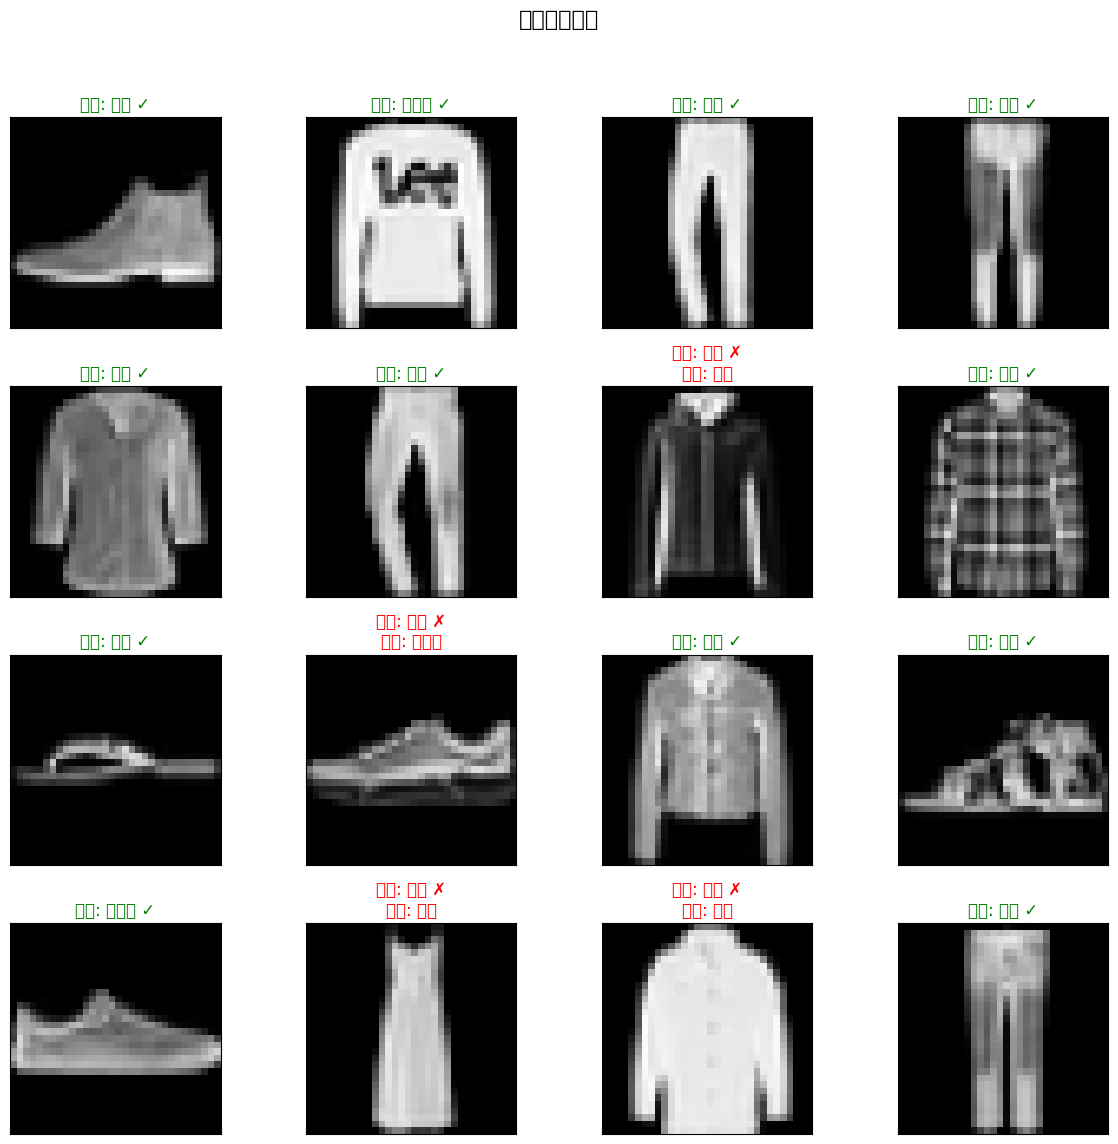

In [ ]:
import matplotlib.pyplot as plt

# 設置模型為評估模式
model.eval()

# 禁用梯度計算
with torch.no_grad():
    # 從測試集隨機取一個 batch 的圖片
    dataiter = iter(test_loader)
    images, labels = next(dataiter)

    # 將圖片移到 device
    images = images.to(device)
    labels = labels.to(device)

    # 預測
    outputs = model(images)
    _, predicted = torch.max(outputs.data, 1)

    # 反標準化函數 (從任務 3 複製)
    def denormalize(image_tensor):
        image_tensor = image_tensor * 0.5 + 0.5
        return image_tensor

    # 顯示前 16 張圖片
    fig = plt.figure(figsize=(12, 12))
    fig.suptitle('模型預測結果', fontsize=16)

    for idx in np.arange(16):
        ax = fig.add_subplot(4, 4, idx + 1, xticks=[], yticks=[])

        # 將圖片從 Tensor 轉為 numpy，並調整維度順序，進行反標準化
        image = denormalize(images[idx].cpu()).permute(1, 2, 0).numpy()
        ax.imshow(image)

        # 判斷預測是否正確
        if predicted[idx].item() == labels[idx].item():
            title_color = 'green'
            title_text = f"預測: {class_names[predicted[idx].item()]} ✓"
        else:
            title_color = 'red'
            title_text = f"預測: {class_names[predicted[idx].item()]} ✗\n正確: {class_names[labels[idx].item()]}"

        ax.set_title(title_text, color=title_color)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # 調整佈局以避免標題重疊
    plt.show()

/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 28310 (\N{CJK UNIFIED IDEOGRAPH-6E96}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 24676 (\N{CJK UNIFIED IDEOGRAPH-6064}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 38263 (\N{CJK UNIFIED IDEOGRAPH-9577}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 35122 (\N{CJK UNIFIED IDEOGRAPH-8932}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_585/4248539964.py:60: UserWarning: Glyph 22871 (\N{CJK UNIFIED IDEOGRAPH-5957}) missi

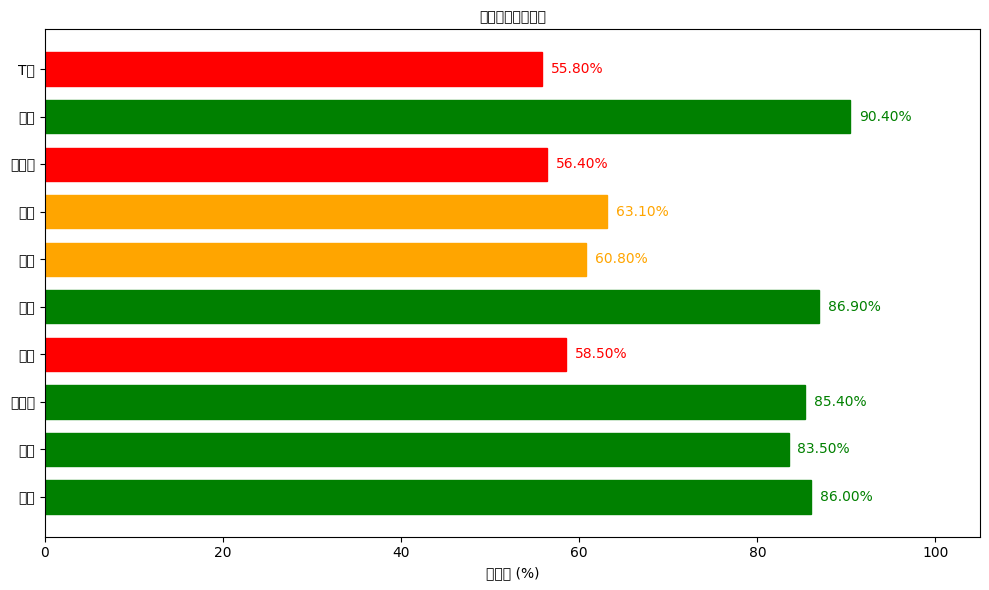

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 設置模型為評估模式
model.eval()

# 初始化每個類別的正確預測數和總數
class_correct = list(0. for i in range(num_classes))
class_total = list(0. for i in range(num_classes))

# 禁用梯度計算
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        c = (predicted == labels).squeeze()
        for i in range(len(labels)):
            label = labels[i]
            class_correct[label] += c[i].item()
            class_total[label] += 1

# 計算並印出每個類別的準確率
class_accuracy = []
for i in range(num_classes):
    if class_total[i] > 0:
        accuracy = 100 * class_correct[i] / class_total[i]
        class_accuracy.append(accuracy)
        # print(f'類別 {class_names[i]} 的準確率: {accuracy:.2f}%')
    else:
        class_accuracy.append(0.0)
        # print(f'類別 {class_names[i]} 沒有測試樣本')

# 視覺化各類別準確率
fig, ax = plt.subplots(figsize=(10, 6))

y_pos = np.arange(len(class_names))
ax.barh(y_pos, class_accuracy, align='center', height=0.7)

ax.set_yticks(y_pos)
ax.set_yticklabels(class_names, fontproperties="Noto Sans CJK TC") # 指定字體以顯示中文
ax.invert_yaxis()  # 最高準確率在上方
ax.set_xlabel('準確率 (%)')
ax.set_title('各類別辨識準確率', fontproperties="Noto Sans CJK TC") # 指定字體以顯示中文

# 標記準確率數字和顏色
for i, v in enumerate(class_accuracy):
    if v >= 80:
        bar_color = 'green'
    elif v >= 60:
        bar_color = 'orange'
    else:
        bar_color = 'red'
    ax.get_children()[i].set_color(bar_color) # 設置長條顏色
    ax.text(v + 1, i, f'{v:.2f}%', color=bar_color, va='center') # 標記文字

# 調整 x 軸範圍，確保標籤不會超出圖形
plt.xlim(0, 105)

plt.tight_layout()
plt.show()

### 📝 任務 6 觀察紀錄

- 準確率最高的類別是哪個？準確率多少？
  **長褲 (Trousers)，準確率 90.4%**
- 準確率最低的類別是哪個？準確率多少？
  **T恤 (T-shirt)，準確率 55.8%**
- 你覺得為什麼某些類別特別難辨識？
  某些類別之間在視覺上可能存在高度相似性，例如「T恤」和「套頭衫」在某些款式上輪廓接近，或「涼鞋」和「運動鞋」在圖片質量不高時可能難以區分細節。這使得模型難以學到足夠的區別特徵。

---
# 任務 7｜建立 Gradio 展示介面 🎮

## 📋 提示詞範本

---
```
請幫我用 Gradio 建立一個圖片分類的展示介面，需求如下：

1. 建立預測函式 predict(image)：
   - 接收一張 PIL Image
   - 對圖片做以下前處理（和測試集一樣）：
     [把你在任務 2 使用的測試集前處理步驟複製貼在這裡]
   - 把圖片加上 batch 維度（unsqueeze(0)）並移到 device
   - 用 model 預測（記得 model.eval() 和 torch.no_grad()）
   - 用 softmax 得到各類別的機率
   - 回傳一個字典：{類別名稱: 機率值}，對應所有 class_names

2. 建立 Gradio Interface：
   - 輸入：gr.Image(type='pil')，標籤「上傳圖片」
   - 輸出：gr.Label(num_top_classes=5)，標籤「預測結果（Top 5）」
   - 標題：「Fashion-MNIST 圖片辨識系統」
   - 說明：「上傳一張圖片，AI 會告訴你它最可能的類別！」

3. 啟動介面：interface.launch()

假設已有：model、class_names、device 變數，model 已訓練完畢。
```
---

## ✅ 成功標準
- 出現網頁連結，點開後有圖片上傳區域
- 上傳圖片後顯示 Top 5 預測結果

## 💡 Demo 建議
拍一件衣服、鞋子或包包上傳測試

In [ ]:
import gradio as gr

# 測試集前處理 (複製任務 2 的設定)
transform_inference = torchvision.transforms.Compose([
    torchvision.transforms.Resize(32),
    torchvision.transforms.Grayscale(num_output_channels=3),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
])

# 預測函式
def predict(image: Image.Image):
    model.eval() # 設置模型為評估模式
    with torch.no_grad(): # 禁用梯度計算
        # 圖片前處理
        image_tensor = transform_inference(image).unsqueeze(0).to(device)

        # 模型預測
        outputs = model(image_tensor)
        probabilities = torch.nn.functional.softmax(outputs, dim=1)[0]

        # 轉換為 {類別名稱: 機率值} 的字典
        return {class_names[i]: float(probabilities[i]) for i in range(len(class_names))}

# 建立 Gradio Interface
interface = gr.Interface(
    fn=predict,
    inputs=gr.Image(type='pil', label='上傳圖片'),
    outputs=gr.Label(num_top_classes=5, label='預測結果（Top 5）'),
    title='Fashion-MNIST 圖片辨識系統',
    description='上傳一張圖片，AI 會告訴你它最可能的類別！'
)

# 啟動介面
interface.launch(inline=True, share=True)


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c5364c4dbeaa3a4505.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


### 📝 任務 7 觀察紀錄

- Gradio 介面成功啟動了嗎？**是**
- 你們測試了幾張圖片？
 4張 鞋子.短褲.長褲.短袖
- 有沒有出現「模型很有把握，但其實猜錯了」的情況？
  有


---
# ★ 挑戰任務 🚀

## 挑戰 A｜解凍更多層（⭐⭐）

**目標：** 任務 4 只訓練最後一層。現在解凍 ResNet 的最後一個 Block（layer4），看看準確率能不能再提升。

```
請幫我修改程式碼，額外解凍 ResNet-18 的 layer4，
讓 layer4 和 FC 層都可以訓練，其他層保持凍結。
用學習率 0.0001（比原本小 10 倍）重新訓練 5 個 Epoch，
比較修改前後的測試準確率差異。
```

In [ ]:
# 挑戰 A：把 Gemini 生成的程式碼貼在這裡



## 挑戰 B｜強化 Gradio 介面（⭐⭐）

自己設計提示詞，讓 Gemini 幫你加入以下任一功能：
- 加入範例圖片（讓介面有預設測試圖片）
- 顯示信心分數長條圖（`gr.BarPlot`）
- 加入類別說明文字

**你的提示詞（請自己寫在下方）：**

```
（在這裡寫下你給 Gemini 的提示詞）
```

In [ ]:
# 挑戰 B：把 Gemini 生成的程式碼貼在這裡



## 挑戰 C｜儲存與重新載入模型（⭐⭐⭐）

自己設計提示詞，讓 Gemini 幫你：
- 把模型儲存到 Google Drive
- 並寫一段重新載入模型的程式碼，確認載入後準確率一樣

**你的提示詞（請自己寫在下方）：**

```
（在這裡寫下你給 Gemini 的提示詞）
```

In [ ]:
# 挑戰 C：把 Gemini 生成的程式碼貼在這裡



---
# 🎯 專題總結報告

### 1. 完成度確認（打勾）
- [ ] 任務 1：環境準備
- [ ] 任務 2：載入資料集
- [ ] 任務 3：探索資料
- [ ] 任務 4：建立模型
- [ ] 任務 5：訓練模型
- [ ] 任務 6：評估模型
- [ ] 任務 7：Gradio 展示介面
- [ ] 挑戰 A：解凍更多層
- [ ] 挑戰 B：強化介面
- [ ] 挑戰 C：儲存模型

### 2. 成果數字

| 項目 | 數值 |
|------|------|
| 使用的資料集 | Fashion-MNIST |
| 訓練 Epoch 數 | |
| 最終測試準確率 | ___% |
| 準確率最高的類別 | （___%) |
| 準確率最低的類別 | （___%) |

### 3. 概念理解（每人填一份）

**Q1：什麼是 Transfer Learning？為什麼要用它而不從頭訓練？**
```
姓名：
（回答）
```

**Q2：在這個專題裡，ResNet-18 的哪些部分被凍結？哪些被訓練？**
```
姓名：
（回答）
```

**Q3：如果想辨識一個全新的主題，你會怎麼用今天學到的方法？**
```
姓名：
（回答）
```

---

## 🏆 完成了！

- ✅ 運用 **Transfer Learning** 完成圖片分類器
- ✅ 訓練模型辨識 **Fashion-MNIST**（10 類）
- ✅ 做出可以讓任何人使用的 **Gradio Demo 介面**

> 💡 成果展示當天，準備好你的 Gradio 連結，拍一件衣服、鞋子或包包上傳測試！